In [1]:
# 🧠 Emoji Predictor - Mini Machine Learning Project
# You can copy-paste this into Google Colab and run it directly!

# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 2: Create a Fun Dataset
data = {
    'text': [
        "I am so happy today", "This is awesome", "What a beautiful day",
        "I love programming", "Feeling great", "That was a fantastic movie",
        "I am very sad", "This is terrible", "I feel so bad",
        "I hate this weather", "Not feeling good", "So disappointed",
        "You are amazing", "I love your smile", "This is wonderful",
        "I'm angry right now", "This is annoying", "You make me mad",
        "I'm scared", "This makes me nervous", "I feel anxious",
        "You are so funny", "That joke made me laugh", "Haha this is hilarious",
        "LOL that’s crazy", "That was so boring", "I feel sleepy",
        "I’m tired of this", "Time to rest", "I need a nap"
    ],
    'emoji': [
        "😄","😄","😄",
        "😍","😄","😍",
        "😢","😢","😢",
        "😡","😢","😢",
        "😍","😍","😍",
        "😡","😡","😡",
        "😨","😨","😨",
        "😂","😂","😂",
        "😂","😴","😴",
        "😴","😴","😴"
    ]
}

df = pd.DataFrame(data)
print("✅ Sample Dataset:")
print(df.head())

# Step 3: Split Data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emoji'], test_size=0.2, random_state=42)

# Step 4: Convert Text to Vectors
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step 5: Train Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Step 6: Evaluate
y_pred = model.predict(X_test_vec)
print("\n🎯 Accuracy:", accuracy_score(y_test, y_pred))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

# Step 7: Test Custom Sentences
def predict_emoji(text):
    text_vec = vectorizer.transform([text])
    prediction = model.predict(text_vec)[0]
    return prediction

print("\n😎 Try Your Own Sentences:")
examples = [
    "I am so happy",
    "This is bad",
    "You are so funny",
    "I feel tired",
    "You make me angry"
]
for ex in examples:
    print(f"{ex} → {predict_emoji(ex)}")

✅ Sample Dataset:
                   text emoji
0   I am so happy today     😄
1       This is awesome     😄
2  What a beautiful day     😄
3    I love programming     😍
4         Feeling great     😄

🎯 Accuracy: 0.0

📊 Classification Report:
               precision    recall  f1-score   support

           😂       0.00      0.00      0.00       1.0
           😍       0.00      0.00      0.00       0.0
           😡       0.00      0.00      0.00       3.0
           😢       0.00      0.00      0.00       1.0
           😴       0.00      0.00      0.00       1.0

    accuracy                           0.00       6.0
   macro avg       0.00      0.00      0.00       6.0
weighted avg       0.00      0.00      0.00       6.0


😎 Try Your Own Sentences:
I am so happy → 😄
This is bad → 😍
You are so funny → 😂
I feel tired → 😴
You make me angry → 😍


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [2]:
# 🧠 Emoji Predictor 2.0 - Real Dataset + Gradio App
# Run this in Google Colab

# Step 1: Install required library
!pip install gradio -q

# Step 2: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import gradio as gr

# Step 3: Create or load a small emoji dataset
# (For demo purposes, we create one here. You can replace with a CSV later)
data = {
    'text': [
        "I love you", "You make me happy", "That was awesome", "Feeling great today",
        "This is terrible", "I am sad", "Why are you so mean", "This is frustrating",
        "That joke was funny", "LOL that's hilarious", "I can’t stop laughing",
        "I feel sleepy", "I am tired", "Time for a nap",
        "I’m scared", "That’s frightening", "This makes me nervous"
    ],
    'emoji': [
        "😍", "😄", "😄", "😄",
        "😢", "😢", "😡", "😡",
        "😂", "😂", "😂",
        "😴", "😴", "😴",
        "😨", "😨", "😨"
    ]
}
df = pd.DataFrame(data)
df.to_csv("emoji_dataset.csv", index=False)  # save for future use
print("✅ Dataset created and saved as emoji_dataset.csv")
print(df.head())

# Step 4: Split and vectorize
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emoji'], test_size=0.2, random_state=42)

vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step 5: Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Step 6: Evaluate
y_pred = model.predict(X_test_vec)
print(f"🎯 Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Step 7: Build a prediction function
def predict_emoji(text):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    return f"Predicted Emoji: {pred}"

# Step 8: Create Gradio Interface
interface = gr.Interface(
    fn=predict_emoji,
    inputs=gr.Textbox(label="Type a sentence here 👇"),
    outputs="text",
    title="😂 Emoji Predictor App",
    description="Type any text and get the most likely emoji prediction!"
)

# Step 9: Launch app
interface.launch(share=True)


✅ Dataset created and saved as emoji_dataset.csv
                  text emoji
0           I love you     😍
1    You make me happy     😄
2     That was awesome     😄
3  Feeling great today     😄
4     This is terrible     😢
🎯 Model Accuracy: 0.00%
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://54acaad6ac9289d015.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# 🧠 Emoji Predictor 3.0 - Save Trained Model to Google Drive
# Run in Google Colab

# Step 1: Install dependencies
!pip install gradio -q

# Step 2: Import libraries
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
import gradio as gr

# Step 3: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 4: Create or load dataset
data = {
    'text': [
        "I love you", "You make me happy", "That was awesome", "Feeling great today",
        "This is terrible", "I am sad", "Why are you so mean", "This is frustrating",
        "That joke was funny", "LOL that's hilarious", "I can’t stop laughing",
        "I feel sleepy", "I am tired", "Time for a nap",
        "I’m scared", "That’s frightening", "This makes me nervous"
    ],
    'emoji': [
        "😍", "😄", "😄", "😄",
        "😢", "😢", "😡", "😡",
        "😂", "😂", "😂",
        "😴", "😴", "😴",
        "😨", "😨", "😨"
    ]
}

df = pd.DataFrame(data)
df.to_csv("emoji_dataset.csv", index=False)
print("✅ Dataset created and saved as emoji_dataset.csv")

# Step 5: Split data
X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emoji'], test_size=0.2, random_state=42)

# Step 6: Vectorize text
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step 7: Train model (Naive Bayes this time)
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# Step 8: Evaluate
y_pred = model.predict(X_test_vec)
print(f"🎯 Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Step 9: Save model and vectorizer to Google Drive
model_path = '/content/drive/MyDrive/emoji_model.pkl'
vectorizer_path = '/content/drive/MyDrive/vectorizer.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)
with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)

print(f"✅ Model saved to Google Drive at: {model_path}")
print(f"✅ Vectorizer saved to Google Drive at: {vectorizer_path}")

# Step 10: Define prediction function
def predict_emoji(text):
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]
    return f"Predicted Emoji: {pred}"

# Step 11: Create Gradio interface
interface = gr.Interface(
    fn=predict_emoji,
    inputs=gr.Textbox(label="Type a sentence here 👇"),
    outputs="text",
    title="😂 Emoji Predictor App",
    description="Type any text and get the most likely emoji prediction!"
)

# Step 12: Launch app
interface.launch(share=True)

Mounted at /content/drive
✅ Dataset created and saved as emoji_dataset.csv
🎯 Model Accuracy: 0.00%
✅ Model saved to Google Drive at: /content/drive/MyDrive/emoji_model.pkl
✅ Vectorizer saved to Google Drive at: /content/drive/MyDrive/vectorizer.pkl
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4558fe1bd98384e9c0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🎯 Model Accuracy: 0.00%


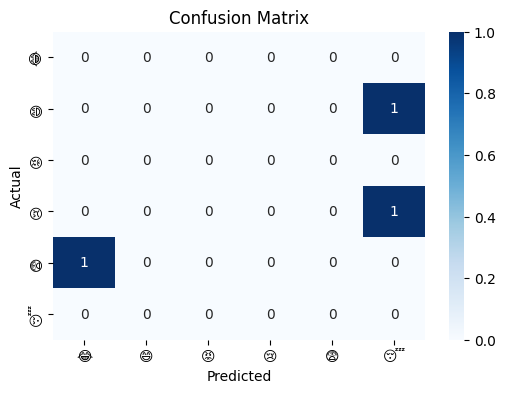

✅ Model & Vectorizer saved to Google Drive
📁 Accuracy logged at: /content/drive/MyDrive/emoji_accuracy_log.txt
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://19e61d281678f3f3d7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# 🧠 Emoji Predictor 4.0 - Accuracy Optimized + TF-IDF + Confusion Matrix + Logging
# Run this in Google Colab

# Step 1: Install dependencies
!pip install gradio seaborn -q

# Step 2: Imports
import pandas as pd
import pickle, re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr
from google.colab import drive

# Step 3: Mount Google Drive
drive.mount('/content/drive')

# Step 4: Create / Load Dataset
data = {
    'text': [
        "I love you", "You make me happy", "That was awesome", "Feeling great today",
        "This is terrible", "I am sad", "Why are you so mean", "This is frustrating",
        "That joke was funny", "LOL that's hilarious", "I can’t stop laughing",
        "I feel sleepy", "I am tired", "Time for a nap",
        "I’m scared", "That’s frightening", "This makes me nervous"
    ],
    'emoji': [
        "😍","😄","😄","😄",
        "😢","😢","😡","😡",
        "😂","😂","😂",
        "😴","😴","😴",
        "😨","😨","😨"
    ]
}
df = pd.DataFrame(data)

# Step 5: Text Cleaning Function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

# Step 6: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(df['clean_text'], df['emoji'], test_size=0.2, random_state=42)

# Step 7: TF-IDF Vectorization
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Step 8: Train Model (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# Step 9: Evaluate Model
y_pred = model.predict(X_test_vec)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {acc*100:.2f}%")

# Step 10: Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Step 11: Save Model + Vectorizer + Accuracy Log to Google Drive
model_path = '/content/drive/MyDrive/emoji_model_v4.pkl'
vectorizer_path = '/content/drive/MyDrive/vectorizer_v4.pkl'
log_path = '/content/drive/MyDrive/emoji_accuracy_log.txt'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)
with open(vectorizer_path, 'wb') as f:
    pickle.dump(vectorizer, f)

with open(log_path, 'a') as f:
    f.write(f"Emoji Predictor v4 Accuracy: {acc*100:.2f}%\n")

print(f"✅ Model & Vectorizer saved to Google Drive\n📁 Accuracy logged at: {log_path}")

# Step 12: Create Prediction Function
def predict_emoji(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    return f"Predicted Emoji: {pred}"

# Step 13: Build Gradio Interface
interface = gr.Interface(
    fn=predict_emoji,
    inputs=gr.Textbox(label="Type a sentence here 👇"),
    outputs="text",
    title="😂 Emoji Predictor 4.0",
    description="Type text and see the best-fit emoji prediction!"
)

# Step 14: Launch App
interface.launch(share=True)